Imports:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from torch.autograd import Variable
from torch.utils.data import random_split

from torchvision import datasets
from torchvision.transforms import ToTensor

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\torchvision\io\image.py:11: UserWarning: Failed to load image Python extension: Could not find module 'A:\ProgrammingStuff\Other\Anaconda3\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warn(f"Failed to load image Python extension: {e}")


In [2]:
# Training function for the MLP
#    Returns the losses and epoch losses
def trainCNN(model, loader, loss_function, optim, num_epochs):
    num_batches = len(loader['train'])

    losses = torch.zeros(num_epochs, num_batches)
    epoch_losses = torch.zeros(num_epochs)

    for epoch in range(num_epochs):
        for batch, (images, labels) in enumerate(loader['train']):
        
            # Grab the batch parameters
            X_batch = Variable(images)
            y_batch = Variable(labels)
        
            # Predict the classes for the batch
            y_pred = model(X_batch)[0]
        
            # Calculate the loss of the batch
            loss = loss_function(y_pred, y_batch)
        
            # Clear the gradient
            optim.zero_grad()
        
            # Apply the gradient
            loss.backward()            
            optim.step()
        
            # store the loss of the batch
            losses[epoch, batch] = loss.item()
        # sotre the loss of the epoch
        epoch_losses[epoch] = sum(losses[epoch]) / num_batches
    return losses, epoch_losses

EMNIST Dataset Initialization:

In [3]:
# Retrieve the EMNIST Balanced dataset and store into the data directory
train_data = datasets.EMNIST(root = 'data', split = 'balanced', train = True, transform = ToTensor(), download = True)
test_data = datasets.EMNIST(root = 'data', split = 'balanced', train = False, transform = ToTensor(), download = True)

# Retrieve the validation data from the training set
train_data, valid_data = random_split(train_data,[90240,22560])

# Retrieve the MNIST Balanced dataset and store into the data directory
train_digits = datasets.MNIST(root='data', download=True, train=True, transform=ToTensor())
test_digits = datasets.MNIST(root='data', download=True, train=False, transform=ToTensor())

# Retrieve the validation data from the training set
train_digits, valid_digits = random_split(train_digits,[50000, 10000])

# Initialize the loader with the EMNIST set
loaders = {
    'train' : torch.utils.data.DataLoader(train_data, batch_size=100, shuffle=True, num_workers=1),
    'test'  : torch.utils.data.DataLoader(test_data, batch_size=100, shuffle=True, num_workers=1),
}

# Initialize the loader with the MNIST set
mnist_loaders = {
    'train' : torch.utils.data.DataLoader(train_digits, batch_size=100, shuffle=True, num_workers=1),
    'test'  : torch.utils.data.DataLoader(test_digits, batch_size=100, shuffle=True, num_workers=1),
}

CNN Model Definition:

In [4]:
# Class definition of the CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Sequential(          
            nn.Conv2d(
                in_channels=1,              
                out_channels=32,            
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),    
        )
        
        self.conv2 = nn.Sequential(         
            nn.Conv2d(
                in_channels=32,              
                out_channels=64,            
                kernel_size=5,              
                stride=1,                   
                padding=2,
            ),     
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),                
        )
        
        self.out = nn.Linear(64 * 7 * 7, 47)
      
    # input x of shape [N, 1, 28, 28]
    def forward(self, x):
        
        # convolucionary layers
        x = self.conv1(x)         # outputs shape N, 32, 14, 14
        x = self.conv2(x)         # outputs shape N, 64, 7, 7
        
        # flatten the output
        x = x.view(x.size(0), -1) # outputs shape N, 3136
        output = self.out(x)      # outputs prediction class (out of 47)
        return output, x

CNN Training:

In [5]:
cnn = CNN()
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr = 0.01)
num_epochs = 10

losses_m, epoch_losses_m = trainCNN(cnn, mnist_loaders, loss_func, optimizer, num_epochs)
losses, epoch_losses = trainCNN(cnn, loaders, loss_func, optimizer, num_epochs)

CNN Test:

In [6]:
totalRight = 0
totalSamples = 0

num_batches = len(loaders['test'])
num_classes = 47

train_accuracies = torch.zeros(num_batches)

total_class_sizes = torch.zeros(num_classes)
total_class_right = torch.zeros(num_classes)

all_labels = []
all_predictions = []

for batch, (images, labels) in enumerate(loaders['test']):
    imgs = Variable(images)
    lbls = Variable(labels)
    
    batchSize = imgs.shape[0]

    test_output, last_layer = cnn(imgs)
    pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()

    batchRight = 0
    batchSamples = 0

    for j in range(0, batchSize):
        batchSamples += 1
        total_class_sizes[lbls[j]] += 1
        if(pred_y[j] == lbls[j]):
            batchRight += 1
            total_class_right[lbls[j]] += 1

    batchAccuracy = batchRight / batchSamples * 100
    
    train_accuracies[batch] = batchAccuracy

    totalRight += batchRight
    totalSamples += batchSamples
    
    all_labels.insert(0, lbls)
    all_predictions.insert(0, pred_y)
    
accuracy = totalRight / totalSamples * 100
print("Test Accuracy : {:.2f}%".format(accuracy))

Test Accuracy : 78.70%


CNN Evaluation:

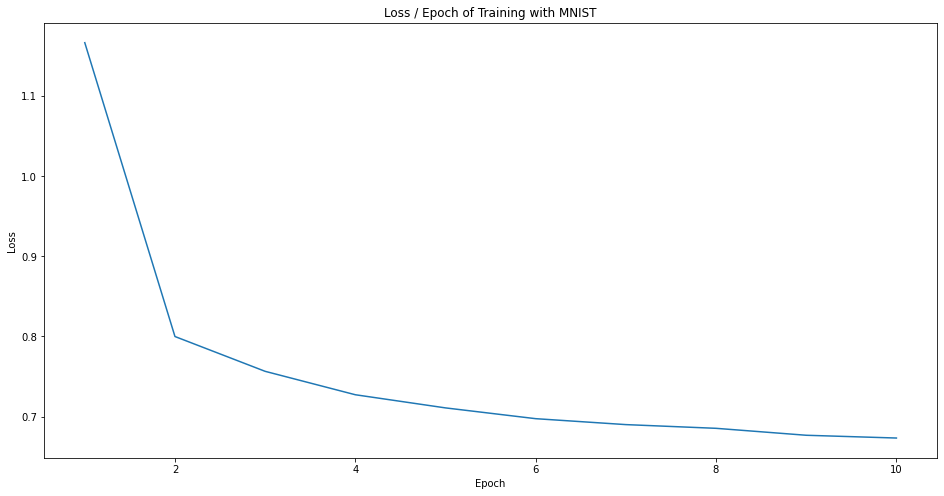

In [7]:
plt.figure(figsize=(16,8))
left = np.arange(1, num_epochs + 1)
plt.plot(left, epoch_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss / Epoch of Training with MNIST')
plt.show()

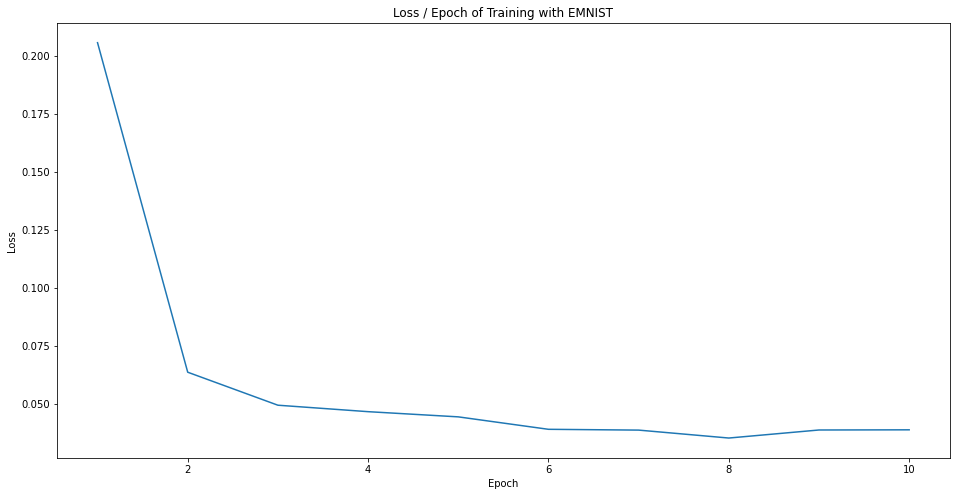

In [8]:
plt.figure(figsize=(16,8))
left = np.arange(1, num_epochs + 1)
plt.plot(left, epoch_losses_m)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss / Epoch of Training with EMNIST')
plt.show()

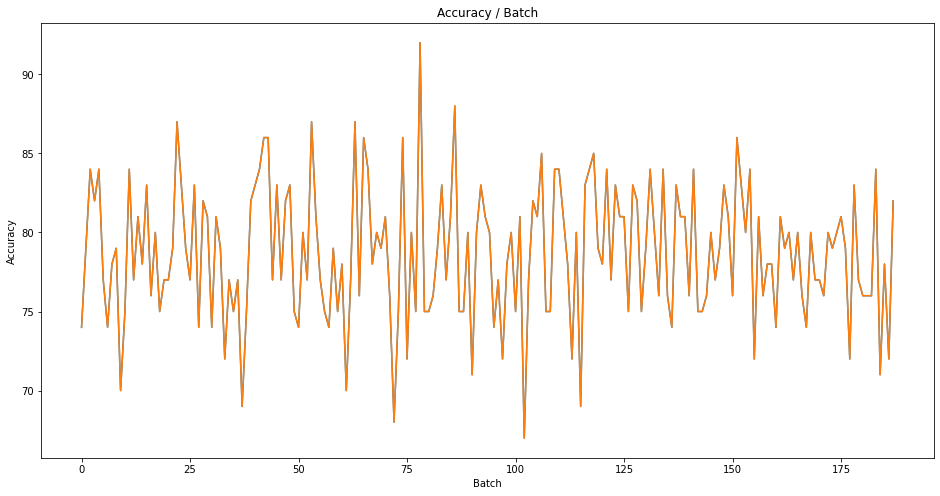

In [9]:
plt.figure(figsize=(16,8))
left = np.arange(0, num_batches) 
plt.plot(left, train_accuracies)
plt.plot(left, train_accuracies)
plt.xlabel('Batch')
plt.ylabel('Accuracy')
plt.title('Accuracy / Batch')
plt.show()

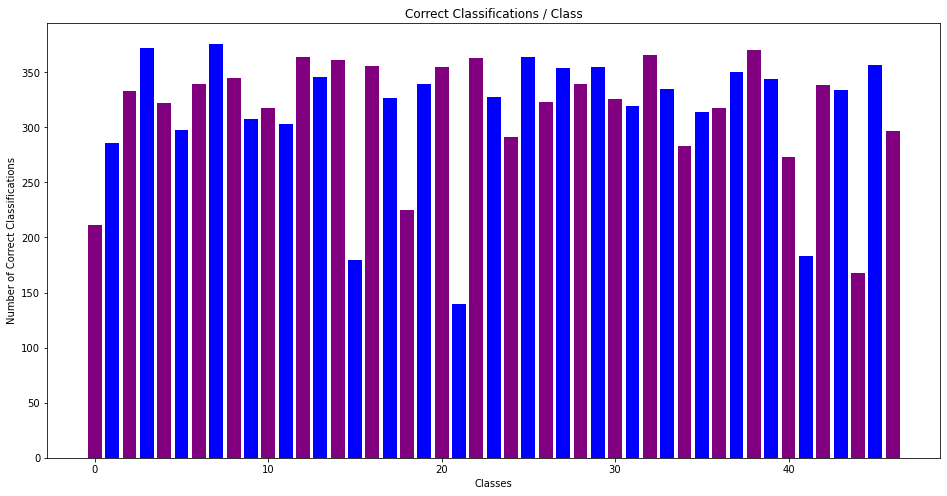

In [10]:
plt.figure(figsize=(16,8))

left = np.arange(0, num_classes) 
height = total_class_right.tolist()
plt.bar(left, height, color = ['purple', 'blue'])
plt.xlabel('Classes')
plt.ylabel('Number of Correct Classifications')
plt.title('Correct Classifications / Class')

plt.show()

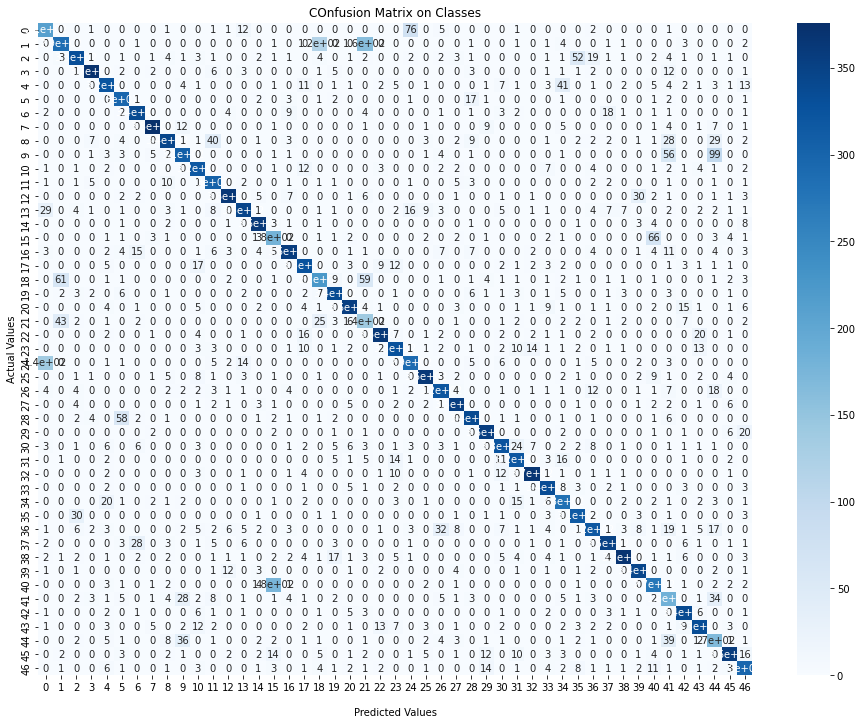

In [11]:
real_y = None
pred_y = None

for lbls in all_labels:
    if real_y is None:
        real_y = lbls
    else:  
        real_y = torch.cat((real_y, lbls), 0)

for pred in all_predictions:
    if pred_y is None:
        pred_y = torch.tensor(pred)
    else:  
        pred_y = torch.cat((pred_y, torch.tensor(pred)), 0)

plt.figure(figsize=(16,12))
cm = confusion_matrix(pred_y, real_y)
ax = sns.heatmap(cm, annot=True, cmap='Blues')
ax.set_title('COnfusion Matrix on Classes');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values');
plt.show()

In [12]:
print(classification_report(real_y, pred_y))

              precision    recall  f1-score   support

           0       0.68      0.53      0.59       400
           1       0.49      0.71      0.58       400
           2       0.74      0.83      0.78       400
           3       0.90      0.93      0.92       400
           4       0.74      0.81      0.77       400
           5       0.90      0.74      0.82       400
           6       0.87      0.85      0.86       400
           7       0.90      0.94      0.92       400
           8       0.71      0.86      0.78       400
           9       0.63      0.77      0.70       400
          10       0.87      0.80      0.83       400
          11       0.89      0.76      0.82       400
          12       0.85      0.91      0.88       400
          13       0.75      0.86      0.81       400
          14       0.93      0.90      0.92       400
          15       0.65      0.45      0.53       400
          16       0.80      0.89      0.84       400
          17       0.84    